In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [6]:
df['Дата'] = pd.to_datetime(df['Дата'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [7]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Сгруппируйте данные по дате, посчитайте количество продаж

In [9]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()

grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Вывести несколько первых строк сгруппированных данных

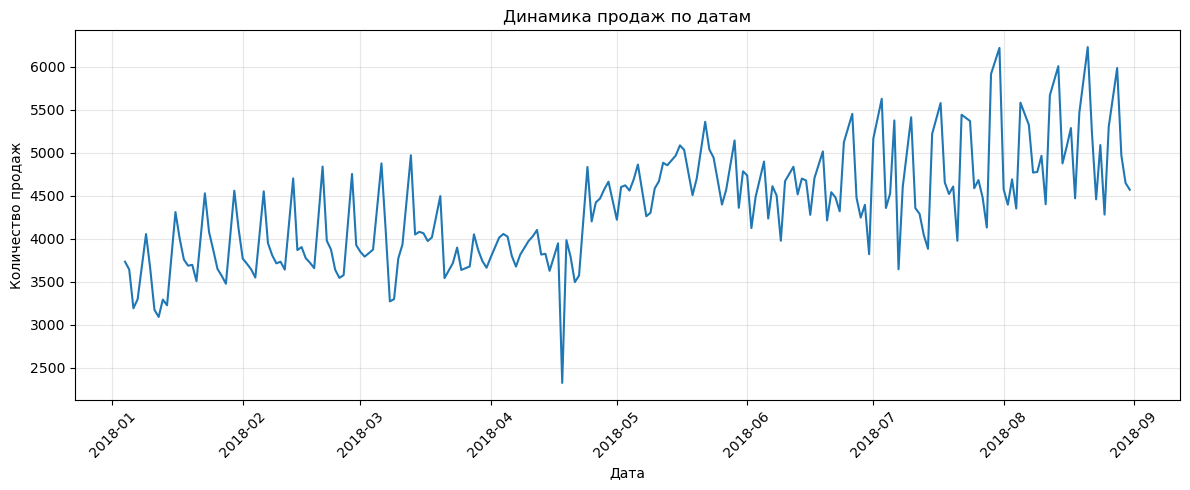

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(grouped_df['Дата'], grouped_df['Количество'])

plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Нарисуйте график продаж у `grouped_df`

На графике виден общий восходящий тренд продаж: с января по август средний уровень продаж постепенно увеличивается. В начале периода значения в основном находятся примерно в диапазоне 3 200–4 500 единиц, а к летним месяцам чаще достигают 4 500–6 000 единиц.  
Наблюдаются регулярные колебания продаж с повторяющимися пиками и снижениями, что может указывать на сезонность или зависимость от дня недели.  
В апреле заметно резкое снижение продаж примерно до 2 300 единиц — это наиболее выраженная аномалия на графике. После этого значения быстро возвращаются к обычному уровню.  
Начиная с мая средний уровень продаж становится выше. В июле–августе увеличивается не только уровень продаж, но и разброс значений: появляются более высокие пики, максимальные значения превышают 6 000 единиц.  
Таким образом, данные показывают рост продаж во времени, наличие регулярных колебаний и отдельный сильный выброс в сторону снижения в апреле.

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [11]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [18]:
months = [6, 7, 8]
month_names = {6: 'Июнь', 7: 'Июль', 8: 'Август'}

filtered_df = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.weekday == 2) &          # среда
    (df['Дата'].dt.month.isin([6, 7, 8]))   # июнь, июль, август
]

sales_by_product = (
    filtered_df
    .groupby('Номенклатура', as_index=False)['Количество']
    .sum()
    .sort_values('Количество', ascending=False)
)

top_product = sales_by_product.iloc[0]

result = pd.DataFrame({
    'Период': ['Июнь, Июль, Август'],
    'Склад': [3],
    'День недели': ['Среда'],
    'Лидер продаж': [top_product['Номенклатура']],
    'Количество продаж': [top_product['Количество']]
})

result

,Период,Склад,День недели,Лидер продаж,Количество продаж
0,"Июнь, Июль, Август",3,Среда,product_1,2267


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [25]:
weather = pd.read_csv(
    '35188.04.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz',
    compression='gzip',
    sep=';',
    encoding='utf-8',
    skiprows=6
)

weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [29]:
weather.columns

weather.index[:5]

Index(['31.08.2018 23:00', '31.08.2018 20:00', '31.08.2018 17:00',
       '31.08.2018 14:00', '31.08.2018 11:00'],
      dtype='object')

In [31]:
weather_daily = pd.DataFrame({
    'Дата_время': weather.index,
    'T': pd.to_numeric(weather['Местное время в Астане'], errors='coerce')
})

weather_daily['Дата_время'] = pd.to_datetime(
    weather_daily['Дата_время'],
    dayfirst=True
)

weather_daily['Дата'] = weather_daily['Дата_время'].dt.normalize()

weather_daily = (
    weather_daily
    .groupby('Дата', as_index=False)['T']
    .mean()
)

weather_daily['T'] = weather_daily['T'].round(1)

weather_daily.head()

,Дата,T
0,2018-01-04,-14.1
1,2018-01-05,-16.9
2,2018-01-06,-13.3
3,2018-01-07,-12.8
4,2018-01-08,-15.4


In [33]:
merged_df = grouped_df.merge(weather_daily, on='Дата', how='inner')

merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.1
1,2018-01-05,3643,-16.9
2,2018-01-06,3193,-13.3
3,2018-01-07,3298,-12.8
4,2018-01-09,4055,-6.2


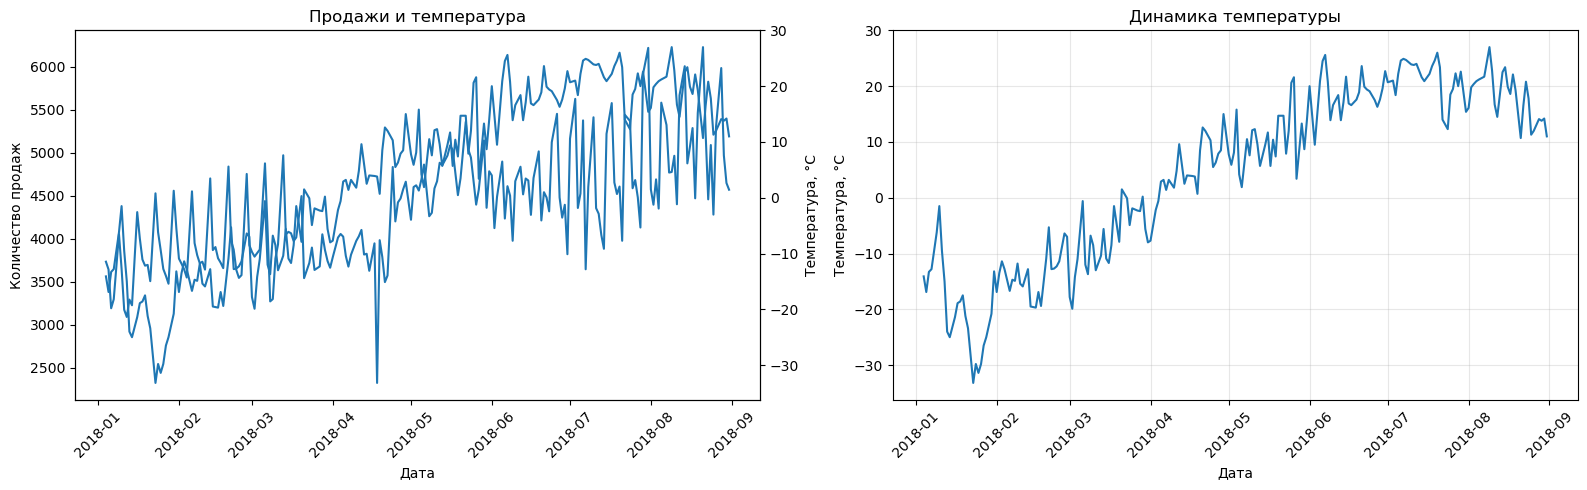

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Продажи + температура
ax1 = axes[0]

ax1.plot(merged_df['Дата'], merged_df['Количество'])
ax1.set_title('Продажи и температура')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж')
ax1.tick_params(axis='x', rotation=45)

ax1_temp = ax1.twinx()
ax1_temp.plot(merged_df['Дата'], merged_df['T'])
ax1_temp.set_ylabel('Температура, °C')

# 2. Температура отдельно
axes[1].plot(merged_df['Дата'], merged_df['T'])
axes[1].set_title('Динамика температуры')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Температура, °C')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

На графике видно, что продажи в целом растут вместе с повышением температуры в течение года, однако зависимость не выглядит прямой. Самый заметный провал продаж в апреле не совпадает с резким изменением температуры. Следовательно, этот выброс, вероятно, связан не с погодными условиями, а с другими факторами: отсутствием товара на складе, снижением активности отдельных контрагентов, праздничными днями, техническими проблемами или особенностями поставок.
Для подтверждения связи температуры и продаж необходимо дополнительно рассчитать корреляцию.

In [38]:
correlation = merged_df['Количество'].corr(merged_df['T'])

print(f'Корреляция между продажами и температурой: {correlation:.2f}')

Корреляция между продажами и температурой: 0.60


Коэффициент корреляции между количеством продаж и температурой составляет 0,60, что говорит о заметной положительной связи. В более тёплые периоды продажи в среднем выше. При этом резкий провал продаж в апреле не сопровождается аналогичным изменением температуры, поэтому отдельные аномалии, вероятно, связаны с другими факторами. Корреляция показывает связь, но не доказывает прямое влияние температуры на продажи.

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

За рассматриваемый период продажи в целом имеют восходящий тренд. Одновременно температура в Астане постепенно повышается от зимних отрицательных значений к летним положительным. Коэффициент корреляции между количеством продаж и температурой составил 0,60, что указывает на заметную положительную связь: в более тёплые периоды продажи в среднем выше. При этом резкий провал продаж в апреле не сопровождается аналогичным снижением температуры, поэтому данная аномалия, скорее всего, связана с другими факторами — поставками, наличием товара, активностью контрагентов или календарными особенностями. Таким образом, температура может быть одним из факторов, связанных с динамикой продаж, но не объясняет все изменения и выбросы.